In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv

C:\Drive D\AI\LangGraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# to load llm credentials
load_dotenv()

True

In [3]:
model = ChatGoogleGenerativeAI(
            model="gemini-2.5-flash",
            temperature=0,
            max_tokens=None,
            timeout=None,
            max_retries=2
        )

In [4]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str

In [7]:
def create_outline(state: BlogState) -> BlogState:
    # fetch title
    title = state['title']
    # call llm gen outline
    prompt = f'Generate a short outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content
    # update state
    state['outline'] = outline
    return state

In [16]:
def create_blog(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']
    prompt = f'Write a short blog on the title - {title} using the following outline \n {outline}'
    content = model.invoke(prompt).content
    state['content'] = content
    return state

In [9]:
graph = StateGraph(BlogState)
# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)
workflow = graph.compile()

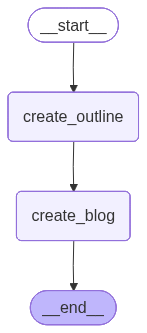

In [19]:
workflow

In [14]:
intial_state = {'title': 'Rise of AI in India'}
final_state = workflow.invoke(intial_state)
print(final_state)

{'title': 'Rise of AI in India', 'outline': 'This detailed outline provides a comprehensive structure for a blog post exploring the "Rise of AI in India." It covers key drivers, applications, challenges, and future prospects, ensuring a well-rounded and informative piece.\n\n---\n\n## Blog Outline: The AI Ascent: How India is Becoming a Global Powerhouse in Artificial Intelligence\n\n**Target Audience:** Tech enthusiasts, business leaders, policymakers, students, general public interested in India\'s technological growth.\n**Tone:** Informative, optimistic, analytical, forward-looking.\n**Keywords:** AI in India, India AI, Artificial Intelligence India, Indian AI startups, NITI Aayog AI, Digital India AI, AI applications India, AI challenges India, India tech growth.\n\n---\n\n### I. Catchy Title & SEO Keywords\n\n*   **Primary Title Options:**\n    *   The AI Ascent: How India is Becoming a Global Powerhouse in Artificial Intelligence\n    *   From Silicon Valley to Silicon India: Cha

In [18]:
#response from outline node
print(final_state['outline'])

This detailed outline provides a comprehensive structure for a blog post exploring the "Rise of AI in India." It covers key drivers, applications, challenges, and future prospects, ensuring a well-rounded and informative piece.

---

## Blog Outline: The AI Ascent: How India is Becoming a Global Powerhouse in Artificial Intelligence

**Target Audience:** Tech enthusiasts, business leaders, policymakers, students, general public interested in India's technological growth.
**Tone:** Informative, optimistic, analytical, forward-looking.
**Keywords:** AI in India, India AI, Artificial Intelligence India, Indian AI startups, NITI Aayog AI, Digital India AI, AI applications India, AI challenges India, India tech growth.

---

### I. Catchy Title & SEO Keywords

*   **Primary Title Options:**
    *   The AI Ascent: How India is Becoming a Global Powerhouse in Artificial Intelligence
    *   From Silicon Valley to Silicon India: Charting the Rise of AI in the Subcontinent
    *   India's AI Re